In [17]:
import pandas as pd
import numpy as np

# 读取数据（从 ts_benchmark/baselines 相对位置）
df = pd.read_csv('../../dataset/forecasting/ETTh1.csv')

# 假设数据格式是 (n*x, 3)，第三列是 cols（列名）
# 获取唯一的列名
unique_cols = df.iloc[:, 2].unique()
print(f"Unique columns found: {unique_cols}")
num_cols = len(unique_cols)

# 获取时间步长
num_samples = len(df) // num_cols

new_dfs = []  # 用于存储新的DataFrame
# 用列名分组
for idx, df_g in enumerate(df.groupby(df.iloc[:, 2])) :
    # print(f"Processing group {idx+1}/{num_cols}: {df_g[0]} with shape {df_g[1].shape}")
    if df_g[1].shape[0] != num_samples:
        print(f"Warning: Group {df_g[0]} has {df_g[1].shape[0]} samples, expected {num_samples}.")

    if idx == 0:
        new_dfs = df_g[1].iloc[:, :-1]# 不要最后一列
        new_dfs.columns = ['date', df_g[0]+'_miss']  # 重命名列
    else:
        df_t = df_g[1].iloc[:, 1]  # 只保留数值列
        df_t.name = df_g[0]+'_miss'  # 设置列名为当前组的列名
        df_t.index = new_dfs.index  # 确保索引对齐
        new_dfs = pd.concat([new_dfs, df_t], axis=1) # 只保留数值列

print(f"Final new_dfs shape: {new_dfs.shape}")
print(new_dfs.head())


df_init = new_dfs.copy()  # 保留原始数据用于后续
df_init.columns = ['date'] + [col.replace('_miss', '') for col in df_init.columns[1:]]  # 恢复原始列名
print(df_init.head())

Unique columns found: ['HUFL' 'HULL' 'MUFL' 'MULL' 'LUFL' 'LULL' 'OT']
Final new_dfs shape: (17420, 8)
                  date  HUFL_miss  HULL_miss  LUFL_miss  LULL_miss  MUFL_miss  \
0  2016-07-01 00:00:00      5.827      2.009      4.203      1.340      1.599   
1  2016-07-01 01:00:00      5.693      2.076      4.142      1.371      1.492   
2  2016-07-01 02:00:00      5.157      1.741      3.777      1.218      1.279   
3  2016-07-01 03:00:00      5.090      1.942      3.807      1.279      1.279   
4  2016-07-01 04:00:00      5.358      1.942      3.868      1.279      1.492   

   MULL_miss    OT_miss  
0      0.462  30.531000  
1      0.426  27.787001  
2      0.355  27.787001  
3      0.391  25.044001  
4      0.462  21.948000  
                  date   HUFL   HULL   LUFL   LULL   MUFL   MULL         OT
0  2016-07-01 00:00:00  5.827  2.009  4.203  1.340  1.599  0.462  30.531000
1  2016-07-01 01:00:00  5.693  2.076  4.142  1.371  1.492  0.426  27.787001
2  2016-07-01 02:00:00  5.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from pygrinder import (
    mnar_x,
    mnar_t,
    mnar_nonuniform,
    mcar,
    seq_missing,
    calc_missing_rate,
    block_missing,
)
# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

data_1_col = new_dfs.iloc[:, 0]
data_without_time = new_dfs.iloc[:, 1:]
data = data_without_time.values.astype(np.float32)

X_mixed = data.reshape(1, data.shape[0], data.shape[1])

missing_20 = {
    "mnar_x_offset": 1.5,
    "mnar_t_cycle": 168,
    "mnar_t_pos": 84,
    "mnar_t_scale": 0.075,
    "mnar_nonuniform_p": 0.03,
    "mnar_nonuniform_increase_factor": 0.6,
    "mcar_p": 0.04,
    "seq_missing_p": 0.03,
    "seq_missing_seq_len": 8,
    "block_missing_factor": 0.005,
    "block_missing_block_width": 3,
    "block_missing_block_len": 5,
}

missing_4 = {
    "mnar_x_offset": 2.5,
    "mnar_t_cycle": 168,
    "mnar_t_pos": 84,
    "mnar_t_scale": 0.058,
    "mnar_nonuniform_p": 0.008,
    "mnar_nonuniform_increase_factor": 0.5,
    "mcar_p": 0.01,
    "seq_missing_p": 0.008,
    "seq_missing_seq_len": 8,
    "block_missing_factor": 0.001,
    "block_missing_block_width": 3,
    "block_missing_block_len": 5,
}

missing_name = "missing_4" 
missing_target = missing_4

def plot_missing_pattern(X, title, step_num):
    """绘制缺失模式"""
    X_2d = X.reshape(X.shape[1], X.shape[2])
    missing_mask = np.isnan(X_2d).astype(int)
    
    # 转置，使特征在x轴，时间在y轴
    missing_mask = missing_mask.T
    
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(missing_mask, cmap='gray', aspect='auto', interpolation='nearest')
    
    ax.set_xlabel('时间维度', fontsize=12)
    ax.set_ylabel('特征维度', fontsize=12)
    ax.set_title(f'{title}\n黑色=缺失, 白色=观测', fontsize=14)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('缺失标记', fontsize=12)
    
    plt.tight_layout()
    # plt.savefig(f'step_{step_num}_missing_pattern.png', dpi=100, bbox_inches='tight')
    plt.show()

# 1. MNAR_X缺失 - 值大于该时间序列均值加上 offset*标准差的数值将被标记为缺失
# 按列调用 mnar_x
# for i in range(X_mixed.shape[2]):
#     X_mixed[:, :, i:i+1] = mnar_x(X_mixed[:, :, i:i+1], offset=missing_target["mnar_x_offset"])
#     print(f"步骤1 - MNAR_X后第{i}列缺失率: {100 * calc_missing_rate(X_mixed[:, :, i:i+1]):.4f} %")

# ETTh1 数据运用 MNAR_X 时，某些列的缺失分布过于集中因此不适用
use_mnar_x = False  # 设置为True以应用MNAR_X缺失
if use_mnar_x:
    # 查看所有列的统计信息
    for i in range(X_mixed.shape[2]):
        col_i = X_mixed[0, :, i]
        
        mean_i = np.mean(col_i)
        std_i = np.std(col_i)

        p90 = np.nanpercentile(col_i, 98)
        print(f"第{i}列 - 大于阈值的数据点比例: {100 * np.sum(col_i > p90) / len(col_i):.4f} %")

        # 计算是几倍的std
        multiplier = (p90 - mean_i) / std_i
        col_i_clean = mnar_x(col_i.reshape(1, -1, 1), offset = multiplier).reshape(-1)  # 应用MNAR_X
        X_mixed[0, :, i] = col_i_clean  # 更新X_mixed中的第i列
        
        print(f"第{i}列 - 当前缺失值数量: {np.sum(np.isnan(col_i_clean))}")
        print("-" * 60)


    # X_mixed = mnar_x(X_mixed, offset=missing_target["mnar_x_offset"])
    current_rate = calc_missing_rate(X_mixed)
    print(f"步骤1 - MNAR_X后缺失率: {100 * current_rate:.4f} %")
    plot_missing_pattern(X_mixed, f"步骤1 - MNAR_X缺失 (缺失率: {100*current_rate:.2f}%)", 1)


步骤2 - MNAR_T后缺失率: 0.9537 %


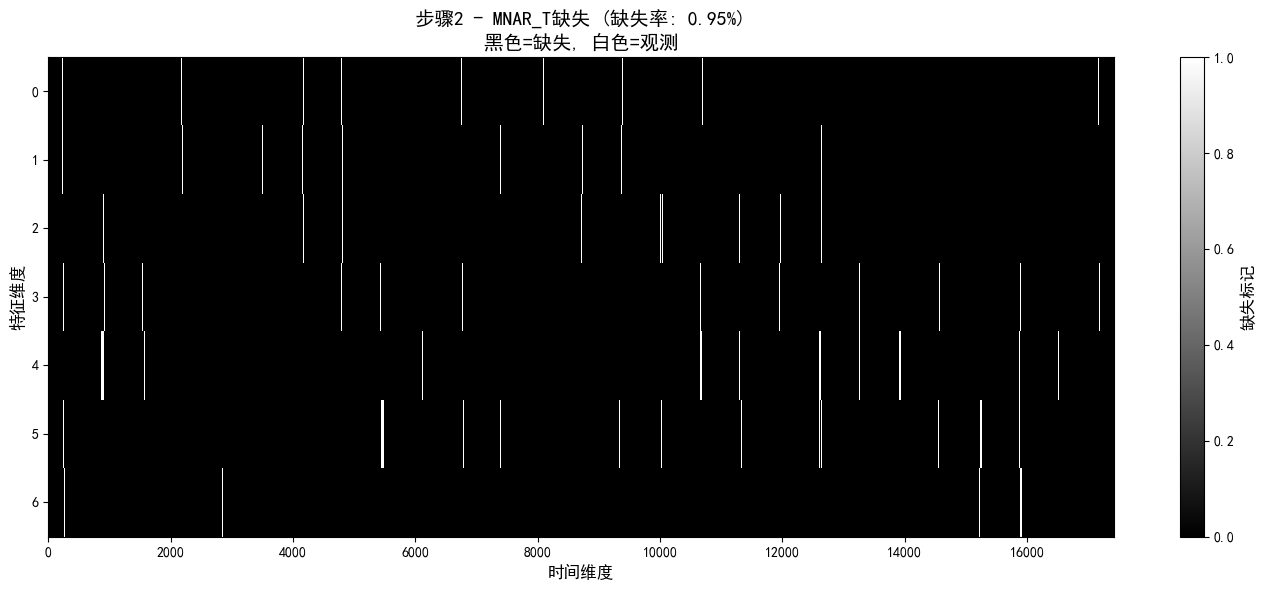

步骤3 - MNAR_Nonuniform后缺失率: 1.7632 %


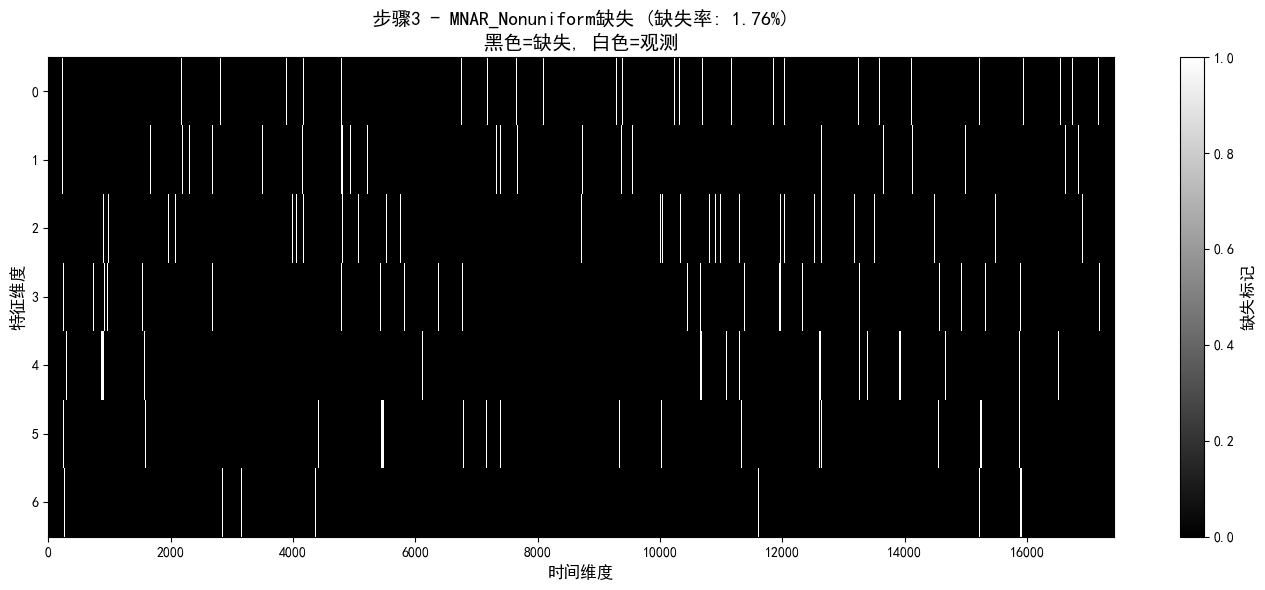

步骤4 - MCAR后缺失率: 2.7514 %


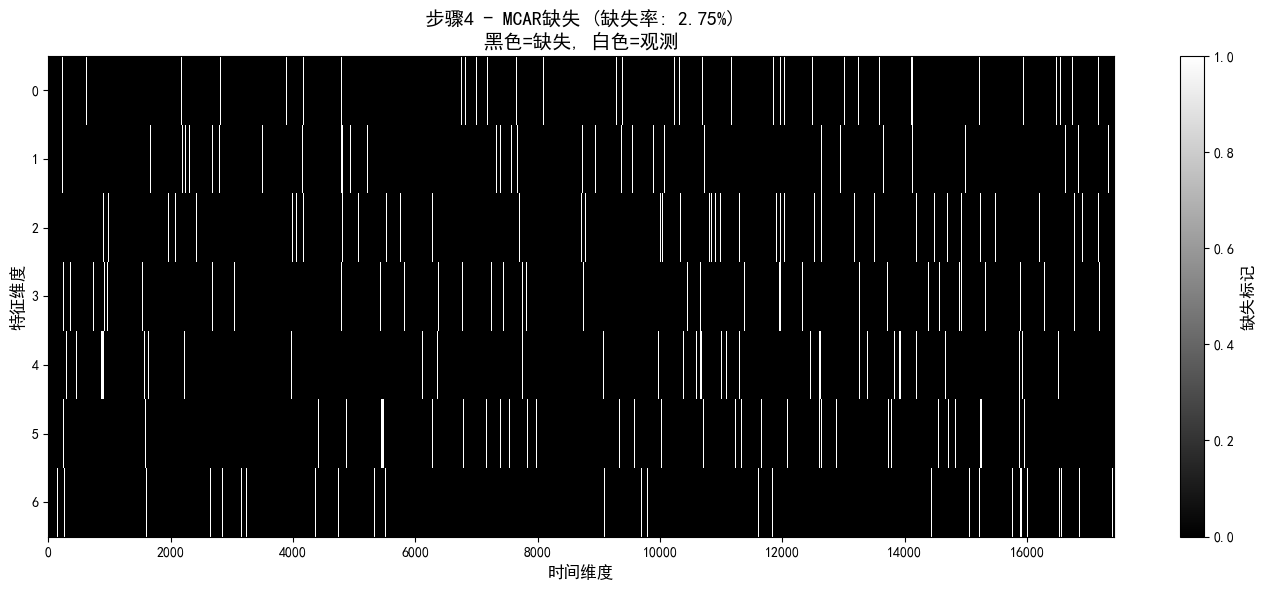

2026-04-28 21:52:25 [WARNING]: hit_rate=17.42 > 1


步骤5 - Seq_Missing后缺失率: 3.5206 %


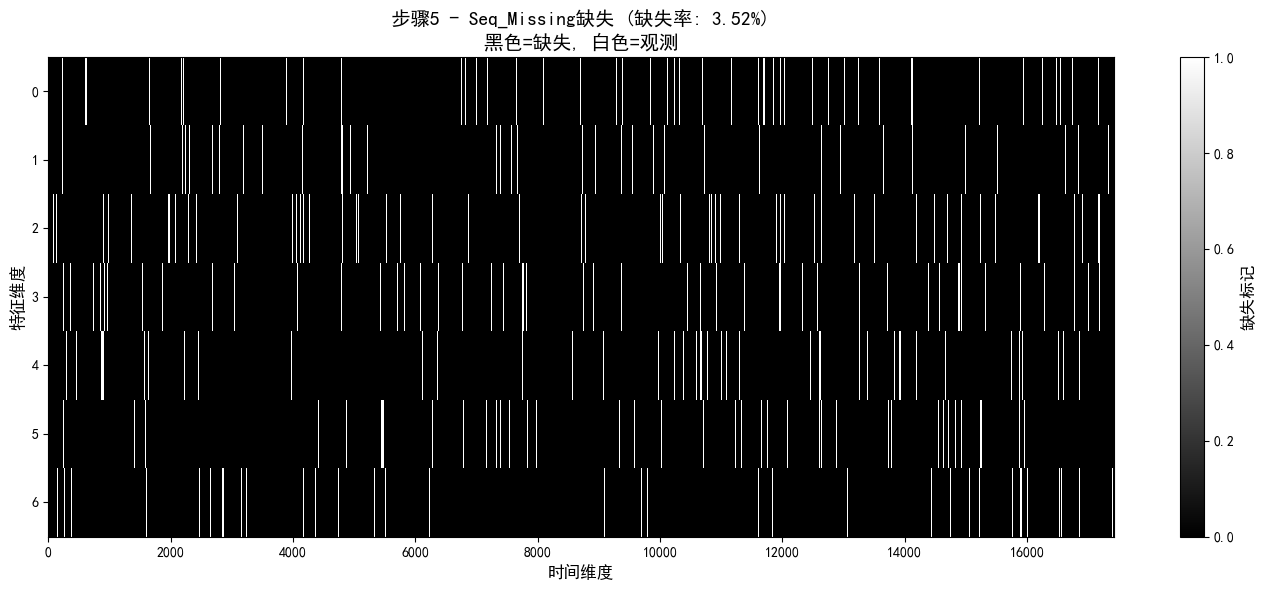

2026-04-28 21:52:25 [WARNING]: hit_rate=8.129333333333333 > 1


步骤6 - Block_Missing后缺失率: 4.0011 %


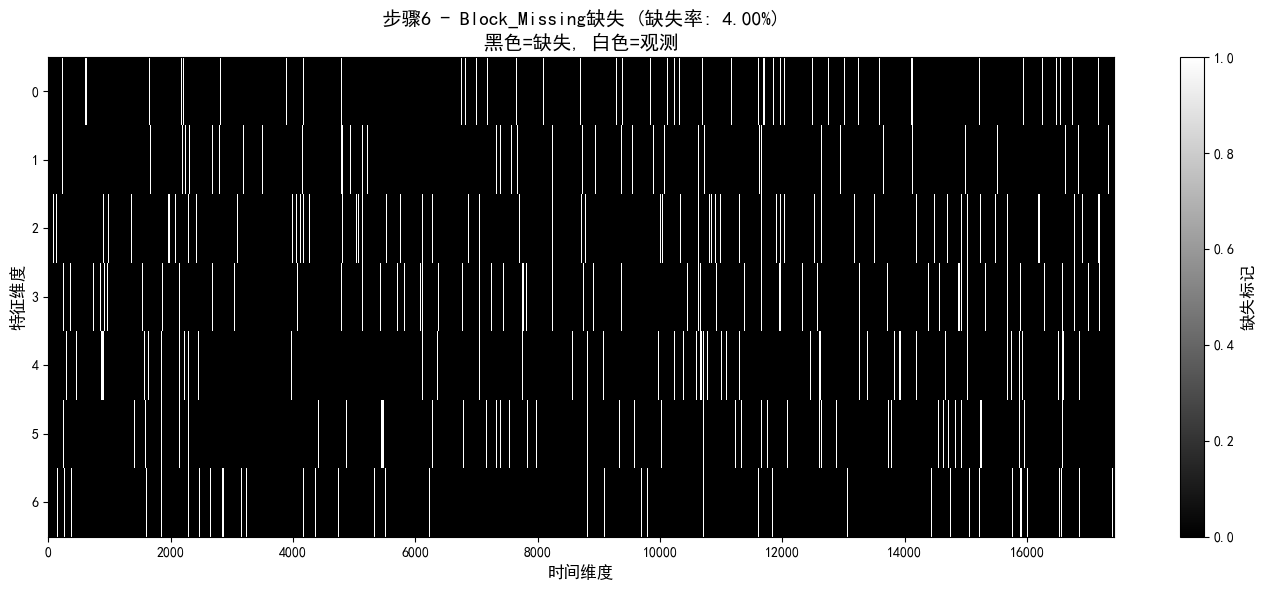

In [19]:

# 2. MNAR_T缺失 - 周期性缺失，缺失性由强度函数 f(t) = exp(scale*torch.sin(cycle*t + pos)) 生成
X_mixed = mnar_t(X_mixed, cycle=missing_target["mnar_t_cycle"], pos=missing_target["mnar_t_pos"], scale=missing_target["mnar_t_scale"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤2 - MNAR_T后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤2 - MNAR_T缺失 (缺失率: {100*current_rate:.2f}%)", 2)

# 3. MNAR_Nonuniform缺失
# 缺失值是根据特征的观测计数引入的，具有可调整的概率，
#     可以为观测不足的特征增加缺失概率。
# p :
#     值可能被标记为缺失的概率。必须在 0 到 1 之间。
#     注意这是目标概率 - 每个特征的实际概率
#     将根据其观测计数进行调整。
# increase_factor :
#         根据观测计数调整替换概率的因子。较高的值
#         将增加从观测不足的特征中删除值的概率。

# 返回-------
# Tuple[Union[np.ndarray, torch.Tensor], Union[np.ndarray, torch.Tensor]] :
#     包含以下内容的元组：
#     - corrupted_X: 包含人工缺失值的原始 X
#     - replacement_probabilities: 用于删除值的概率
X_mixed_result = mnar_nonuniform(X_mixed, p=missing_target["mnar_nonuniform_p"], 
                                 increase_factor=missing_target["mnar_nonuniform_increase_factor"])
X_mixed = X_mixed_result[0]
current_rate = calc_missing_rate(X_mixed)
print(f"步骤3 - MNAR_Nonuniform后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤3 - MNAR_Nonuniform缺失 (缺失率: {100*current_rate:.2f}%)", 3)

# 4. MCAR缺失 - 完全随机缺失,每个值以p概率独立缺失
X_mixed = mcar(X_mixed, p=missing_target["mcar_p"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤4 - MCAR后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤4 - MCAR缺失 (缺失率: {100*current_rate:.2f}%)", 4)

# 5. Seq_Missing缺失 - 序列缺失（每个时间步以p概率开始一个长度为seq_len的缺失序列）
X_mixed = seq_missing(X_mixed, p=missing_target["seq_missing_p"], seq_len=missing_target["seq_missing_seq_len"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤5 - Seq_Missing后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤5 - Seq_Missing缺失 (缺失率: {100*current_rate:.2f}%)", 5)

# 6. Block_Missing缺失 - 块缺失（每个时间步以factor概率开始一个宽度为block_width、长度为block_len的缺失块）
X_mixed = block_missing(X_mixed, factor=missing_target["block_missing_factor"], 
                        block_width=missing_target["block_missing_block_width"], block_len=missing_target["block_missing_block_len"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤6 - Block_Missing后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤6 - Block_Missing缺失 (缺失率: {100*current_rate:.2f}%)", 6)

# 转换回2D
X_mixed = X_mixed.reshape(data_without_time.shape)

# 最终缺失率
# final_rate = calc_missing_rate(X_mixed)
# print(f"\n最终缺失率: {100 * final_rate:.4f} %")
# plot_missing_pattern(X_mixed.reshape(1, X_mixed.shape[0], X_mixed.shape[1]), 
#                      f"最终 - 混合缺失 (总缺失率: {100*final_rate:.2f}%)", 'final')

# 加回时间列
X_mixed = np.hstack((data_1_col.values.reshape(-1, 1), X_mixed))  # 将时间列与缺失数据合并

In [20]:
missing_data = pd.DataFrame(X_mixed.copy())  # 这是最终的缺失数据
missing_data.columns = new_dfs.columns.tolist()  # 设置列名与new_dfs一致

# 增加t_idx, t_dif, mask列
missing_data['t_idx'] = np.arange(len(new_dfs))

for col in missing_data.columns[1:-1]:
    # mask：1=有值，0=缺失
    mask = missing_data[col].notna().astype(int)
    missing_data[f'mask_{col}'] = mask

    # 上一次观测时间
    last_valid_t = missing_data['t_idx'].where(mask == 1).ffill()

    # 时间间隔
    t_dif = missing_data['t_idx'] - last_valid_t

    # ⭐ 关键：缺失位置才累加，有值位置必须是0
    t_dif = t_dif.where(mask == 0, 0)

    missing_data[f't_dif_{col}'] = t_dif

# print(f"Final new_dfs shape: {missing_data.shape}")
# print(missing_data.head(10))
# print(new_dfs.columns.tolist())
# 将数据转换成(n*3)*3的格式,列名分别为 date	data cols 其中date是时间戳，data是数值，cols是列名


missing_data.columns = new_dfs.columns.tolist() + ['t_idx'] + missing_data.columns[len(new_dfs.columns)+1:].tolist()

original_cols = new_dfs.columns.tolist()[1:]  # 除去date列
mask_cols = [f'mask_{col}' for col in original_cols]
t_dif_cols = [f't_dif_{col}' for col in original_cols]
# 调整列顺序，确保 date 在第一列，t_idx 在最后一列，且其他列按照 new_dfs 的顺序排列，mask放一块，t_dif放一块

final_data = missing_data[['date'] + original_cols + mask_cols + t_dif_cols + ['t_idx']]
# 加入原始数据用于计算loss，并保存填充后的数据
final_data = pd.concat([df_init.iloc[:, 1:], final_data], axis=1)  # 保留原始列，其他列使用填充后的数据
print(final_data.columns.tolist())
# print(final_data.head(5))

def convert_to_tfb_series(data):
    data = data.set_index("date")
    melted_df = data.melt(value_name="data", var_name="cols", ignore_index=False)
    return melted_df.reset_index()[['date', 'data', 'cols']]


# 保存填充前的数据
tmp_final_data = final_data.copy()  # convert完后保存
melted_df = convert_to_tfb_series(tmp_final_data)
melted_df.to_csv(f"../../dataset/forecasting/ETTh1_{missing_name}.csv", index=False)

# 弄一个只有10条数据的测试
final_data_10 = tmp_final_data.head(10)
melted_df_10 = convert_to_tfb_series(final_data_10)
melted_df_10.to_csv(f"../../dataset/forecasting/ETTh1_10test.csv", index=False)


# 对列名末尾为_miss的列进行插值填充
# 查看final_data有多少值是缺失
print(f"填充前的缺失数量{final_data.isna().sum().sum()}")

for col in final_data.columns:
    if col.endswith('_miss'):
        final_data[col] = final_data[col].astype(float)  # 保证是数值
        final_data[col] = final_data[col].interpolate(method='linear', limit_direction='both')
        # print(f"列 {col} - 当前缺失值数量: {final_data[col].isna().sum()}")
print(f"填充后的缺失数量{final_data.isna().sum().sum()}")

print(final_data.columns.tolist())




# 保存最终数据
final_data_10 = final_data.head(10).copy()

final_data = convert_to_tfb_series(final_data)
final_data_10 = convert_to_tfb_series(final_data_10)


final_data.to_csv(f"../../dataset/forecasting/ETTh1_{missing_name}_filled.csv", index=False)
melted_df_10.to_csv(f"../../dataset/forecasting/ETTh1_{missing_name}_filled_10.csv", index=False)




['HUFL', 'HULL', 'LUFL', 'LULL', 'MUFL', 'MULL', 'OT', 'date', 'HUFL_miss', 'HULL_miss', 'LUFL_miss', 'LULL_miss', 'MUFL_miss', 'MULL_miss', 'OT_miss', 'mask_HUFL_miss', 'mask_HULL_miss', 'mask_LUFL_miss', 'mask_LULL_miss', 'mask_MUFL_miss', 'mask_MULL_miss', 'mask_OT_miss', 't_dif_HUFL_miss', 't_dif_HULL_miss', 't_dif_LUFL_miss', 't_dif_LULL_miss', 't_dif_MUFL_miss', 't_dif_MULL_miss', 't_dif_OT_miss', 't_idx']
填充前的缺失数量4880
填充后的缺失数量0
['HUFL', 'HULL', 'LUFL', 'LULL', 'MUFL', 'MULL', 'OT', 'date', 'HUFL_miss', 'HULL_miss', 'LUFL_miss', 'LULL_miss', 'MUFL_miss', 'MULL_miss', 'OT_miss', 'mask_HUFL_miss', 'mask_HULL_miss', 'mask_LUFL_miss', 'mask_LULL_miss', 'mask_MUFL_miss', 'mask_MULL_miss', 'mask_OT_miss', 't_dif_HUFL_miss', 't_dif_HULL_miss', 't_dif_LUFL_miss', 't_dif_LULL_miss', 't_dif_MUFL_miss', 't_dif_MULL_miss', 't_dif_OT_miss', 't_idx']
